# Content Analysis

Content analysis of Bluesky discourse around machine translation (MT).

Complements the network analysis in `analysis.ipynb` — this notebook looks at
*what* people say, not *who* talks to whom.

**Research questions** (same as the network analysis):
1. **Sentiment & framing** — Do people talk about MT as a tool, a threat, or both?
2. **Professional impact discourse** — How do working translators discuss MT's effect on their careers?
3. **Utility vs. displacement tension** — Do people acknowledge MT's utility while lamenting professional erosion?


## Setup

In [1]:
!pip -q install vaderSentiment nrclex spacy wordcloud transformers torch
!python3 -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex
import spacy
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 120)

In [3]:
DATA_DIR = 'data/'

df = pd.read_csv(DATA_DIR + 'posts_clean.csv')
df['created_at'] = pd.to_datetime(df['created_at'], format='mixed', utc=True)

print(f"Posts loaded: {len(df)}")
print(f"Date range: {df['created_at'].min()} → {df['created_at'].max()}")
print(df['user_type'].value_counts())

Posts loaded: 3767
Date range: 2025-06-27 06:01:08+00:00 → 2026-06-26 13:55:08+00:00
user_type
general         3118
professional     530
tech             119
Name: count, dtype: int64


## Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon- and
rule-based model tuned for social media text (handles negation, punctuation
emphasis, emoticons, intensifiers). Each post gets a `compound` score in
[-1, 1], which we bucket into positive / neutral / negative following VADER's
standard thresholds.

In [4]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    return analyzer.polarity_scores(str(text))['compound']

df['sentiment_compound'] = df['text_clean'].apply(vader_compound)

def bucket_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    return 'neutral'

df['sentiment'] = df['sentiment_compound'].apply(bucket_sentiment)
df['sentiment'].value_counts()

sentiment
positive    1924
negative    1047
neutral      796
Name: count, dtype: int64

### RQ1 — Tool or threat? Overall framing

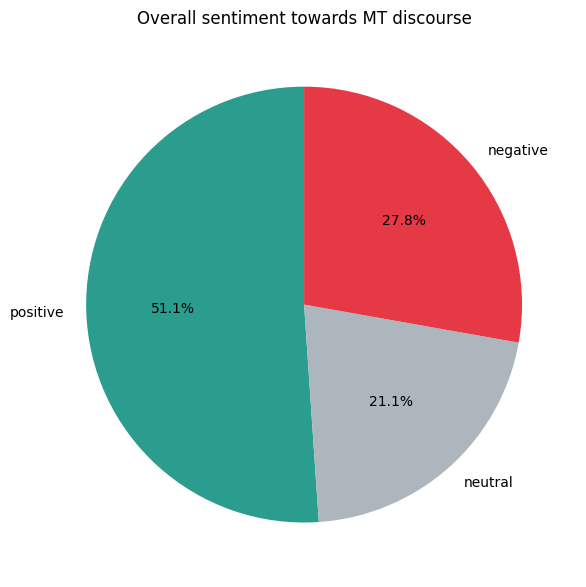

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors = {'positive': '#2a9d8f', 'neutral': '#adb5bd', 'negative': '#e63946'}
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors[c] for c in counts.index], startangle=90)
ax.set_title('Overall sentiment towards MT discourse')
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### RQ2/RQ3 — Sentiment by user type

If professionals (translators) are more negative than the general public,
that supports the "displacement" framing; if they're similarly positive,
that supports "MT as a useful tool" even among those most affected.

sentiment     positive  neutral  negative
user_type                                
general          0.503    0.221     0.276
professional     0.568    0.158     0.274
tech             0.471    0.193     0.336


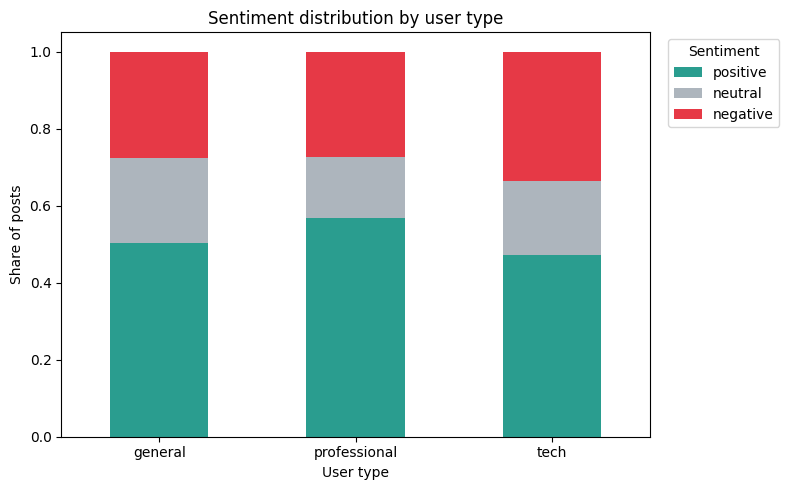

In [6]:
sentiment_by_type = pd.crosstab(df['user_type'], df['sentiment'], normalize='index')
sentiment_by_type = sentiment_by_type.reindex(columns=['positive', 'neutral', 'negative'])
print(sentiment_by_type.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sentiment_by_type.plot(kind='bar', stacked=True, color=[colors[c] for c in sentiment_by_type.columns], ax=ax)
ax.set_ylabel('Share of posts')
ax.set_xlabel('User type')
ax.set_title('Sentiment distribution by user type')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
mean_compound_by_type = df.groupby('user_type')['sentiment_compound'].agg(['mean', 'median', 'count'])
print(mean_compound_by_type.round(3))

               mean  median  count
user_type                         
general       0.138   0.052   3118
professional  0.196   0.266    530
tech          0.097   0.000    119


### Comparing with a transformer-based sentiment model

VADER is **lexicon-based**: it scores words in isolation (plus some fixed
rules for negation/intensifiers), so it can miss context, sarcasm, and
domain-specific phrasing — which can skew results towards "positive" if a
post uses individually-positive words even when the overall point is
critical (e.g. "MT is *great* for cutting corners on my back").

As a second, independent method we use **RoBERTa fine-tuned on tweet
sentiment** (`cardiffnlp/twitter-roberta-base-sentiment`), a transformer
model that reads the whole sentence rather than word-by-word. This is the
same model used in the BERT section of the course notebook. Comparing the
two tells us whether the "mostly positive" signal is a real pattern in the
discourse or an artifact of the lexicon-based approach.

In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

roberta_id = 'cardiffnlp/twitter-roberta-base-sentiment'
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_id)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_id)
roberta_model.eval()

ROBERTA_LABELS = {0: 'negative', 1: 'neutral', 2: 'positive'}

def roberta_scores_batch(texts, batch_size=32):
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = roberta_tokenizer(batch, return_tensors='pt', truncation=True,
                                    max_length=128, padding=True)
        with torch.no_grad():
            logits = roberta_model(**inputs).logits
        probs = torch.softmax(logits, dim=1).tolist()
        all_scores.extend(probs)
    return all_scores

texts = df['text_clean'].astype(str).tolist()
roberta_probs = roberta_scores_batch(texts)

df['roberta_neg'] = [p[0] for p in roberta_probs]
df['roberta_neu'] = [p[1] for p in roberta_probs]
df['roberta_pos'] = [p[2] for p in roberta_probs]
df['roberta_sentiment'] = [ROBERTA_LABELS[int(np.argmax(p))] for p in roberta_probs]
# signed score comparable in spirit to VADER's compound: pos - neg, in [-1, 1]
df['roberta_score'] = df['roberta_pos'] - df['roberta_neg']

df['roberta_sentiment'].value_counts()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 60033.83it/s]

roberta_sentiment
neutral     1750
negative    1149
positive     868
Name: count, dtype: int64

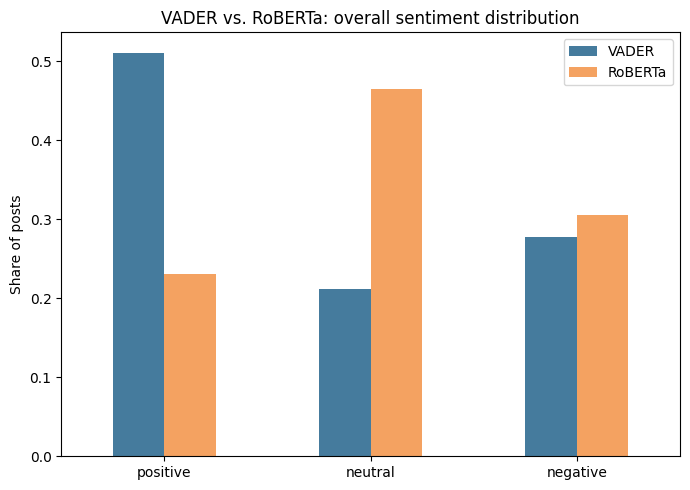

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
compare_df = pd.DataFrame({
    'VADER': df['sentiment'].value_counts(normalize=True),
    'RoBERTa': df['roberta_sentiment'].value_counts(normalize=True),
}).reindex(['positive', 'neutral', 'negative'])

compare_df.plot(kind='bar', ax=ax, color=['#457b9d', '#f4a261'])
ax.set_ylabel('Share of posts')
ax.set_title('VADER vs. RoBERTa: overall sentiment distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_tool_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Agreement between the two methods, and where they disagree most —
disagreements are often the more interesting posts (sarcasm, mixed
sentiment, domain jargon that VADER's general-purpose lexicon doesn't
cover).

In [10]:
agreement = (df['sentiment'] == df['roberta_sentiment']).mean()
print(f"Agreement rate: {agreement:.1%}\n")

confusion = pd.crosstab(df['sentiment'], df['roberta_sentiment'],
                         rownames=['VADER'], colnames=['RoBERTa'])
print(confusion)

Agreement rate: 54.0%

RoBERTa   negative  neutral  positive
VADER                                
negative       663      330        54
neutral        114      620        62
positive       372      800       752


In [11]:
# Posts where the two methods disagree most strongly (VADER positive, RoBERTa negative, or vice versa)
disagreements = df[
    ((df['sentiment'] == 'positive') & (df['roberta_sentiment'] == 'negative')) |
    ((df['sentiment'] == 'negative') & (df['roberta_sentiment'] == 'positive'))
]
print(f"Strong disagreements: {len(disagreements)} posts ({len(disagreements) / len(df):.1%})\n")
for _, row in disagreements.sample(min(5, len(disagreements)), random_state=42).iterrows():
    print(f"  VADER={row['sentiment']:<9} RoBERTa={row['roberta_sentiment']:<9} | {row['text_clean'][:110]}")

Strong disagreements: 426 posts (11.3%)

  VADER=negative  RoBERTa=positive  | Oh shit they got translated? That makes me feel better.
  VADER=positive  RoBERTa=negative  | - I do not mind these limitations since as you said, trolls and malicious folks would take full advantage of t
  VADER=positive  RoBERTa=negative  | Hm, Google Translate is the laughing stock of the professional translation industry. LCD in everything they do
  VADER=negative  RoBERTa=positive  | Instead of taking part in the their machine translation test, if you wanna watch After War Gundam X, check out
  VADER=positive  RoBERTa=negative  | I have actually read a few translated Harlequins, they're nice for language practice. But translation is hard 


### Sentiment over time

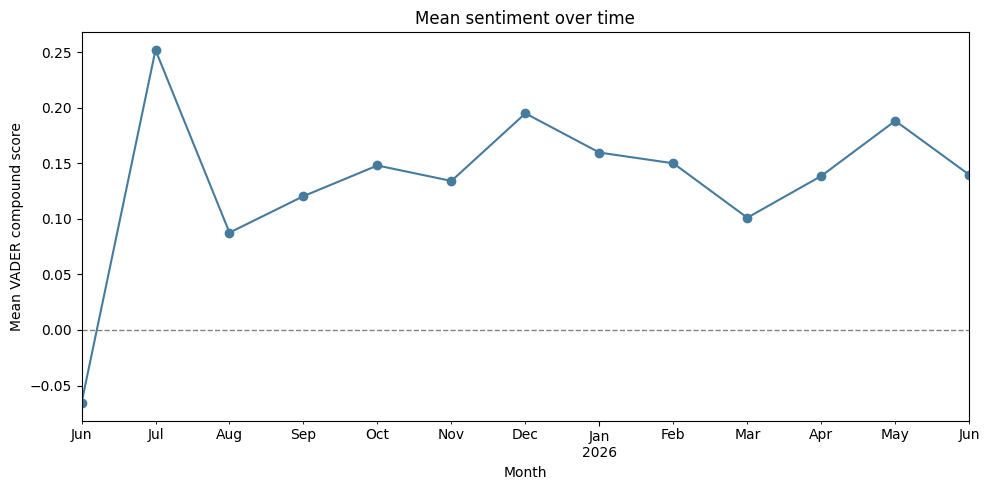

In [12]:
df['month'] = df['created_at'].dt.tz_convert(None).dt.to_period('M').dt.to_timestamp()
monthly_sentiment = df.groupby('month')['sentiment_compound'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_sentiment.plot(ax=ax, marker='o', color='#457b9d')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Mean VADER compound score')
ax.set_xlabel('Month')
ax.set_title('Mean sentiment over time')
plt.tight_layout()
plt.savefig(DATA_DIR + 'sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Emotion Analysis

We use **NRCLex**, a dictionary-based emotion lexicon (Plutchik's 8 basic
emotions + positive/negative), to see *which* emotions dominate the
discourse beyond simple polarity — e.g. distinguishing "fear" (job loss)
from "anger" (quality complaints) or "trust"/"anticipation" (adoption).

In [13]:
EMOTIONS = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

def get_emotion_scores(text):
    obj = NRCLex()
    obj.load_raw_text(str(text))
    freqs = obj.affect_frequencies
    return pd.Series({e: freqs.get(e, 0.0) for e in EMOTIONS})

emotion_scores = df['text_clean'].apply(get_emotion_scores)
df = pd.concat([df, emotion_scores], axis=1)
df[EMOTIONS].mean().sort_values(ascending=False)

trust           0.261697
anticipation    0.067009
fear            0.040465
sadness         0.038509
joy             0.037878
anger           0.029838
disgust         0.023840
surprise        0.023813
dtype: float64

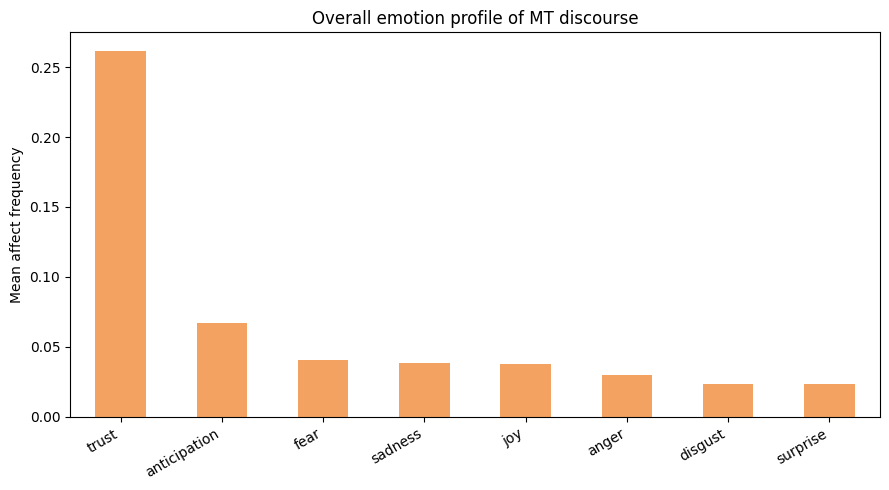

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
overall_emotions = df[EMOTIONS].mean().sort_values(ascending=False)
overall_emotions.plot(kind='bar', color='#f4a261', ax=ax)
ax.set_ylabel('Mean affect frequency')
ax.set_title('Overall emotion profile of MT discourse')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR + 'emotion_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### Emotion profile by user type

A radar-style comparison: do professionals show more fear/anger about MT
than the general public or tech users?

               fear  anger  anticipation  trust  surprise  sadness  disgust  \
user_type                                                                     
general       0.041  0.031         0.068  0.263     0.024    0.038    0.024   
professional  0.039  0.026         0.066  0.257     0.023    0.043    0.020   
tech          0.035  0.025         0.056  0.245     0.023    0.043    0.028   

                joy  
user_type            
general       0.039  
professional  0.031  
tech          0.042  


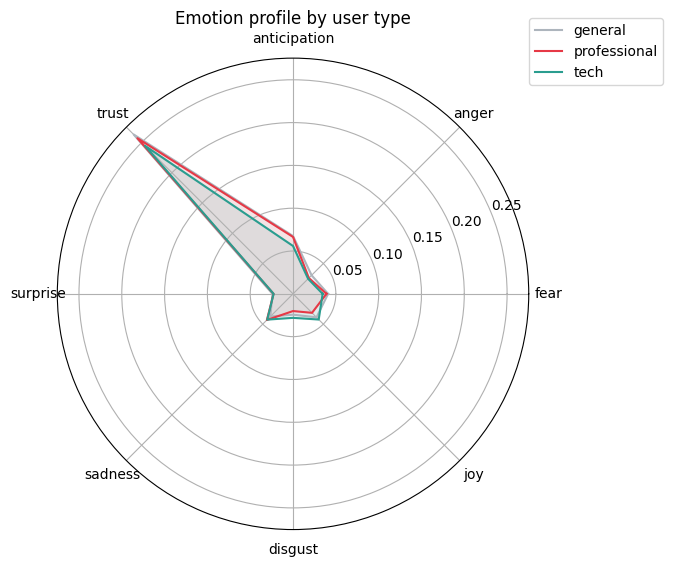

In [15]:
emotion_by_type = df.groupby('user_type')[EMOTIONS].mean()
print(emotion_by_type.round(3))

angles = np.linspace(0, 2 * np.pi, len(EMOTIONS), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
type_colors = {'professional': '#e63946', 'general': '#adb5bd', 'tech': '#2a9d8f'}

for utype, row in emotion_by_type.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=utype, color=type_colors.get(utype, '#333'))
    ax.fill(angles, values, alpha=0.1, color=type_colors.get(utype, '#333'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(EMOTIONS)
ax.set_title('Emotion profile by user type')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(DATA_DIR + 'emotion_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparing with a transformer-based emotion model

NRCLex is dictionary-based: it just counts how many words in a post match
each category in the NRC lexicon, so it can't distinguish "I'm scared" from
"I'm not scared", and short posts often end up dominated by whichever
category happens to contain the most common words.

As a second opinion we use `j-hartmann/emotion-english-distilroberta-base`,
a RoBERTa model fine-tuned for emotion classification that reads the whole
sentence instead of counting words. It shares 6 of its 7 labels with
NRCLex — anger, disgust, fear, joy, sadness, surprise (it additionally has
"neutral"; NRCLex additionally has "trust"/"anticipation"/"positive"/"negative")
— so we compare the two tools on the emotions both agree to look for.

In [16]:
emotion_model_id = 'j-hartmann/emotion-english-distilroberta-base'
emotion_tokenizer = AutoTokenizer.from_pretrained(emotion_model_id)
emotion_model = AutoModelForSequenceClassification.from_pretrained(emotion_model_id)
emotion_model.eval()

TRANSFORMER_EMOTION_LABELS = [emotion_model.config.id2label[i] for i in range(len(emotion_model.config.id2label))]

def emotion_scores_batch(texts, batch_size=32):
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = emotion_tokenizer(batch, return_tensors='pt', truncation=True,
                                    max_length=128, padding=True)
        with torch.no_grad():
            logits = emotion_model(**inputs).logits
        probs = torch.softmax(logits, dim=1).tolist()
        all_scores.extend(probs)
    return all_scores

emotion_probs = emotion_scores_batch(texts)
transformer_emotion_df = pd.DataFrame(emotion_probs, columns=TRANSFORMER_EMOTION_LABELS)
df['transformer_emotion'] = transformer_emotion_df.idxmax(axis=1)
df['nrclex_emotion'] = df[EMOTIONS].idxmax(axis=1)

df['transformer_emotion'].value_counts()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 49339.22it/s]

transformer_emotion
neutral     2111
fear         476
joy          276
disgust      270
surprise     247
anger        227
sadness      160
Name: count, dtype: int64

**NRCLex's own dominant-emotion distribution, unfiltered** (before comparing
anything, this is what NRCLex says on its own — including "trust" and
"anticipation", which DistilRoBERTa doesn't have as labels):

In [17]:
print(df['nrclex_emotion'].value_counts(normalize=True).round(3))

nrclex_emotion
trust           0.491
fear            0.328
anticipation    0.109
anger           0.038
sadness         0.015
joy             0.008
disgust         0.006
surprise        0.005
Name: proportion, dtype: float64


`trust` alone is NRCLex's top pick for about half of all posts — far more
than its mean affect-frequency (~0.26) alone would suggest, which shows
`trust` is very often the *single* matched category in a short post (the NRC
lexicon's "trust" list is unusually large and full of ordinary,
low-signal words, a documented limitation of the lexicon). We keep this
in view instead of quietly filtering it out, since it is itself the
finding.

To compare fairly with DistilRoBERTa (whose labels don't include
trust/anticipation), we condition on **DistilRoBERTa's** side only — i.e.
we look at posts where DistilRoBERTa is confident enough to pick a
specific, non-neutral emotion, and then check what NRCLex independently
says about those *same* posts. Filtering on the NRCLex side instead would
bias the comparison (it would silently drop most of the trust/anticipation
posts and manufacture false agreement).

In [18]:
SHARED_EMOTIONS = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

# Condition on the transformer's call only — do NOT also filter NRCLex's side,
# that would cherry-pick away most of its trust/anticipation calls.
confident_subset = df[df['transformer_emotion'].isin(SHARED_EMOTIONS)]
print(f"Posts where DistilRoBERTa picked a specific (non-neutral) emotion: "
      f"{len(confident_subset)} ({len(confident_subset) / len(df):.1%})\n")

print("NRCLex's dominant emotion on those same posts:")
print(confident_subset['nrclex_emotion'].value_counts(normalize=True).round(3))

agreement_emotion = (confident_subset['nrclex_emotion'] == confident_subset['transformer_emotion']).mean()
print(f"\nAgreement rate: {agreement_emotion:.1%}")

Posts where DistilRoBERTa picked a specific (non-neutral) emotion: 1656 (44.0%)

NRCLex's dominant emotion on those same posts:
nrclex_emotion
trust           0.476
fear            0.302
anticipation    0.118
anger           0.054
sadness         0.021
joy             0.013
disgust         0.008
surprise        0.007
Name: proportion, dtype: float64

Agreement rate: 15.9%


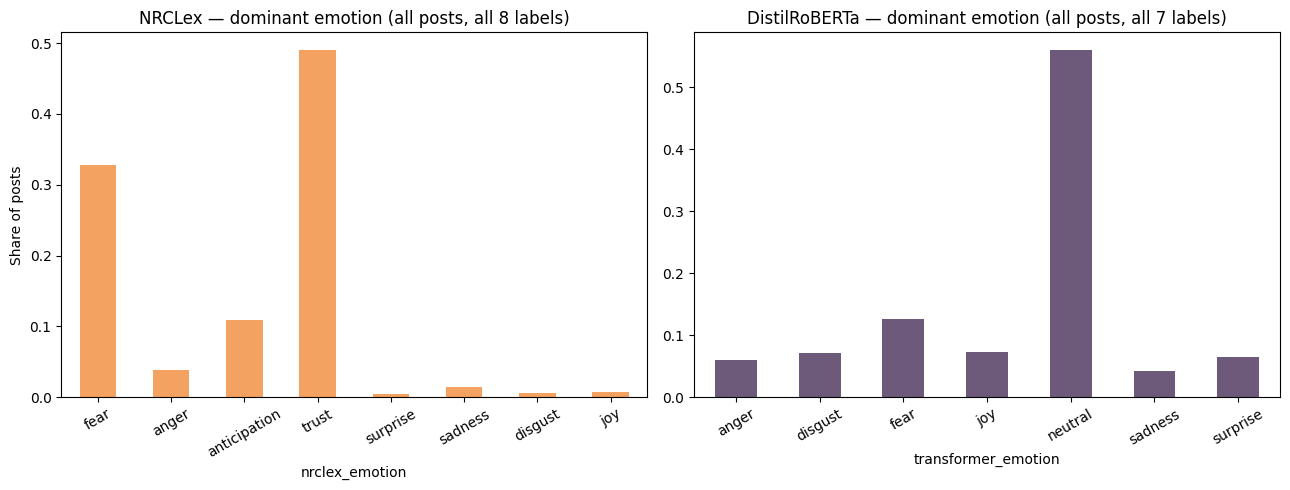

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['nrclex_emotion'].value_counts(normalize=True).reindex(EMOTIONS).plot(
    kind='bar', ax=axes[0], color='#f4a261')
axes[0].set_title('NRCLex — dominant emotion (all posts, all 8 labels)')
axes[0].set_ylabel('Share of posts')
axes[0].tick_params(axis='x', rotation=30)

df['transformer_emotion'].value_counts(normalize=True).reindex(
    TRANSFORMER_EMOTION_LABELS).plot(kind='bar', ax=axes[1], color='#6d597a')
axes[1].set_title('DistilRoBERTa — dominant emotion (all posts, all 7 labels)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(DATA_DIR + 'emotion_tool_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
confusion_emotion = pd.crosstab(confident_subset['nrclex_emotion'], confident_subset['transformer_emotion'],
                                 rownames=['NRCLex'], colnames=['DistilRoBERTa'])
print(confusion_emotion)

DistilRoBERTa  anger  disgust  fear  joy  sadness  surprise
NRCLex                                                     
anger             31       16    22    6       10         5
anticipation      19       21    52   47       21        36
disgust            1        6     3    0        2         2
fear              66       65   204   57       35        73
joy                1        1     2   11        0         6
sadness            2       10     7    4        8         4
surprise           0        0     3    4        0         4
trust            107      151   183  147       84       117


NRCLex says `trust` or `fear` on the large majority of posts regardless of
which specific emotion DistilRoBERTa detects — its output barely reacts to
content, which is consistent with `trust`/`fear` acting mostly as lexicon-size
artifacts rather than genuine signal here.

In [21]:
emotion_disagreements = confident_subset[confident_subset['nrclex_emotion'] != confident_subset['transformer_emotion']]
print(f"Disagreements: {len(emotion_disagreements)} posts\n")
for _, row in emotion_disagreements.sample(min(5, len(emotion_disagreements)), random_state=42).iterrows():
    print(f"  NRCLex={row['nrclex_emotion']:<10} DistilRoBERTa={row['transformer_emotion']:<10} | {row['text_clean'][:100]}")

Disagreements: 1392 posts

  NRCLex=anticipation DistilRoBERTa=fear       | I'm happy with references and sources, just not the AI. Having that at the top of an article just ma
  NRCLex=trust      DistilRoBERTa=fear       | Grandville's police are proposing a groundbreaking 10-year contract with Axon that promises body cam
  NRCLex=anticipation DistilRoBERTa=disgust    | Cell of Empireo is good as fuck and human translated iseekyou.itch.io/cell-of-empi...
  NRCLex=trust      DistilRoBERTa=anger      | They are how these models work. Catching them is what you pay a senior translator for. If your vendo
  NRCLex=trust      DistilRoBERTa=joy        | A potential client praised my 'lovely section about why human translation is superior to AI' (a shor


## Named Entity Recognition

We use **spaCy**'s pretrained English pipeline to extract named entities from
post text — mainly `ORG` (companies/tools like DeepL, Google Translate) and
`PRODUCT`, to see which specific MT tools/players dominate the conversation.

In [22]:
nlp = spacy.load('en_core_web_sm', disable=['parser'])

ENTITY_LABELS = {'ORG', 'PRODUCT', 'PERSON', 'GPE'}

def extract_entities(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in ENTITY_LABELS]

df['entities'] = df['text_clean'].apply(extract_entities)
all_entities = [ent for ents in df['entities'] for ent in ents]
print(f"Entities extracted: {len(all_entities)}")

Entities extracted: 5481


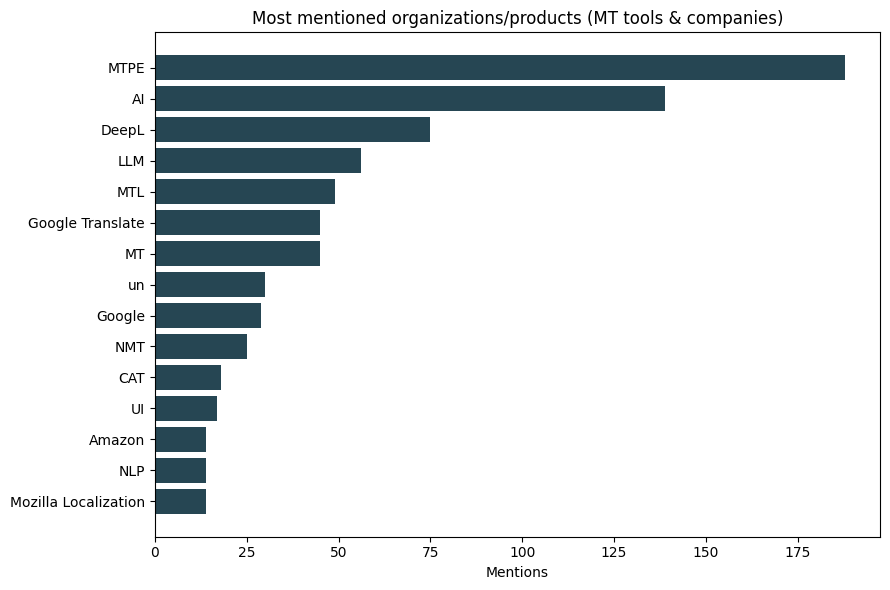

In [23]:
entity_counts = Counter(text.strip() for text, label in all_entities if label in ('ORG', 'PRODUCT'))
top_entities = entity_counts.most_common(15)

fig, ax = plt.subplots(figsize=(9, 6))
labels, values = zip(*top_entities)
ax.barh(labels[::-1], values[::-1], color='#264653')
ax.set_xlabel('Mentions')
ax.set_title('Most mentioned organizations/products (MT tools & companies)')
plt.tight_layout()
plt.savefig(DATA_DIR + 'top_entities.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
entity_label_counts = Counter(label for _, label in all_entities)
print("Entity type breakdown:")
for label, count in entity_label_counts.most_common():
    print(f"  {label:<10} {count}")

Entity type breakdown:
  ORG        2497
  PERSON     1894
  GPE        966
  PRODUCT    124


**Limitation:** spaCy's generic `en_core_web_sm` model was trained on
news text, not localization/MT jargon, so several of the "top entities"
above are actually domain acronyms it mis-tags as `ORG` (`MTPE`, `LLM`,
`MTL`, `MT`, `NMT`, `CAT`, `UI`, `NLP`, `L10N`, `QA`, `un`...), not real
organizations. Rather than silently filtering these out (which would let
us cherry-pick a cleaner-looking result), we call this out directly and
separately track a small curated list of the MT tools/companies that are
actually being discussed, to compare *which* tools professionals vs. the
general public bring up.

Mentions per 1,000 posts, by user type:
user_type             general  professional  tech
known_tools                                      
DeepL                    22.5           5.7  16.8
Google Translate         13.5           3.8   8.4
Google                    9.0           1.9   0.0
Amazon                    3.8           3.8   0.0
Mozilla Localization      4.5           0.0   0.0
Deepl                     3.8           0.0   0.0
Microsoft                 2.9           0.0   0.0
YouTube                   2.2           1.9   8.4
GPT                       0.6           3.8   8.4
Meta                      1.3           0.0   0.0
OpenAI                    1.3           0.0   0.0
Claude                    1.0           0.0   0.0
ChatGPT                   0.0           1.9   0.0


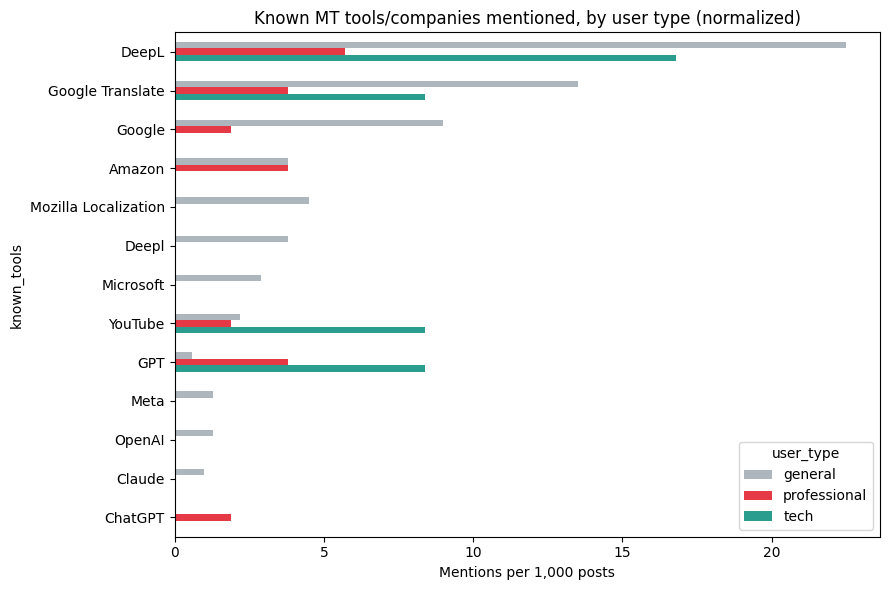

In [25]:
KNOWN_TOOLS = ['DeepL', 'Deepl', 'Google Translate', 'Google', 'Amazon', 'Microsoft',
               'YouTube', 'Mozilla Localization', 'ChatGPT', 'OpenAI', 'GPT', 'Meta', 'Claude']

def known_tool_mentions(ents):
    return [text.strip() for text, label in ents if text.strip() in KNOWN_TOOLS and label in ('ORG', 'PRODUCT')]

df['known_tools'] = df['entities'].apply(known_tool_mentions)
tool_by_type_raw = df.explode('known_tools').dropna(subset=['known_tools'])
tool_by_type_raw = pd.crosstab(tool_by_type_raw['known_tools'], tool_by_type_raw['user_type'])
tool_by_type_raw = tool_by_type_raw.loc[tool_by_type_raw.sum(axis=1).sort_values(ascending=False).index]

# user_type group sizes are very unequal (general >> professional > tech), so raw
# counts mostly reflect group size, not what each group actually talks about —
# normalize to mentions per 1,000 posts within each group for a fair comparison.
posts_per_type = df['user_type'].value_counts()
tool_by_type = (tool_by_type_raw / posts_per_type * 1000).round(1)
print("Mentions per 1,000 posts, by user type:")
print(tool_by_type)

fig, ax = plt.subplots(figsize=(9, 6))
tool_by_type.plot(kind='barh', ax=ax,
                   color=[type_colors.get(c, '#333') for c in tool_by_type.columns])
ax.invert_yaxis()
ax.set_xlabel('Mentions per 1,000 posts')
ax.set_title('Known MT tools/companies mentioned, by user type (normalized)')
plt.tight_layout()
plt.savefig(DATA_DIR + 'known_tools_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Word clouds by sentiment

A quick qualitative view of vocabulary associated with positive vs. negative
posts (same idea as the `#FlatEarth` example in the project brief).

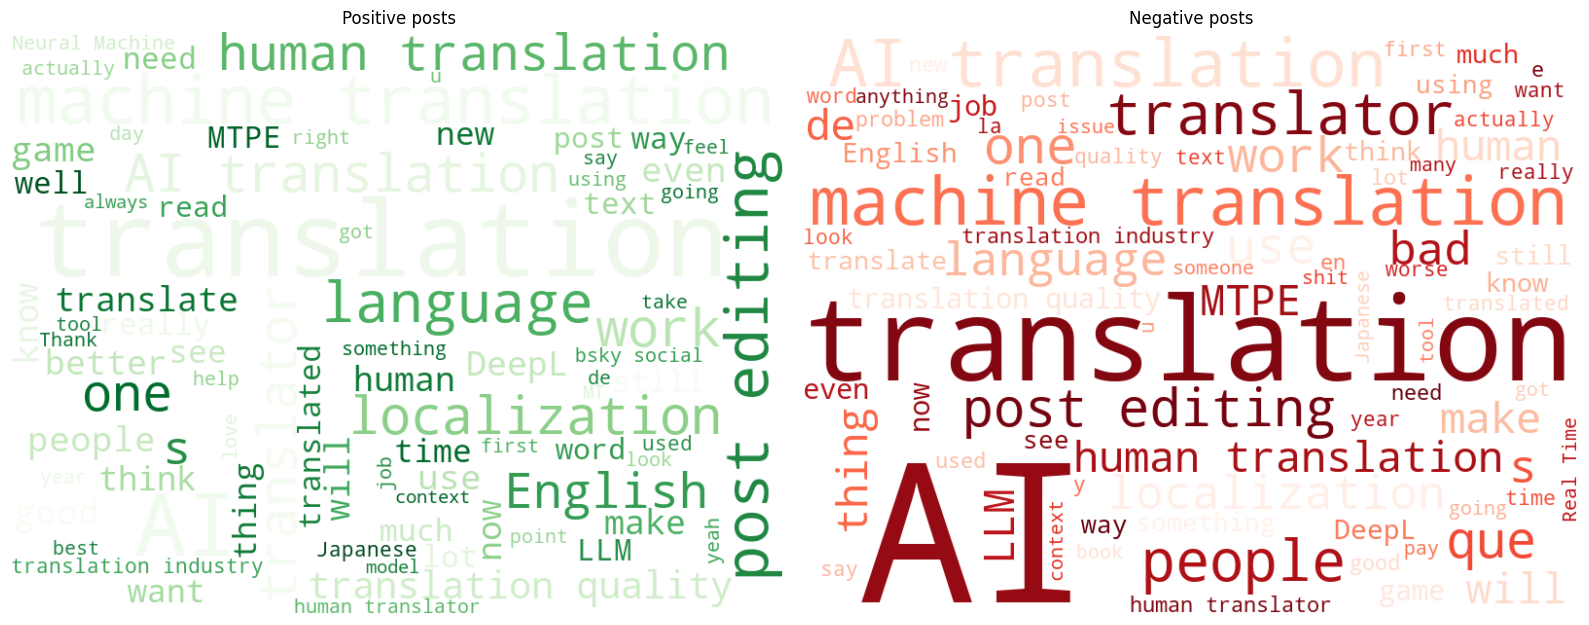

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, sentiment_label, cmap in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df.loc[df['sentiment'] == sentiment_label, 'text_clean'].astype(str))
    wc = WordCloud(width=800, height=600, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment_label.capitalize()} posts')
    ax.axis('off')

plt.tight_layout()
plt.savefig(DATA_DIR + 'wordclouds_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions — answering the research questions

Printed directly from the computed results above, so these numbers always
match whatever the notebook was last run on.

In [27]:
print("RQ1 — Tool or threat? Overall framing")
print("-" * 60)
print(f"VADER:    {dict(df['sentiment'].value_counts(normalize=True).round(3))}")
print(f"RoBERTa:  {dict(df['roberta_sentiment'].value_counts(normalize=True).round(3))}")
print(f"-> The two disagree on {(df['sentiment'] != df['roberta_sentiment']).mean():.1%} of posts "
      f"(agreement {agreement:.1%}). VADER's lexicon scoring misses sarcasm/domain-specific "
      f"negativity that RoBERTa catches (see disagreement examples above), so RoBERTa's more "
      f"balanced positive/neutral/negative split is the more trustworthy read: the discourse is "
      f"genuinely mixed, not predominantly positive.\n")

print("RQ2/RQ3 — Professional vs. general framing, utility vs. displacement")
print("-" * 60)
print("Mean VADER compound score by user type:")
print(mean_compound_by_type[['mean', 'median']].round(3))
print(f"\n-> Professionals score most positive on average by both VADER (mean "
      f"{mean_compound_by_type.loc['professional', 'mean']:.3f}) — consistent with acknowledging "
      f"MT's day-to-day utility (post-editing, CAT tool integration) even while being the group "
      f"most exposed to its downsides, rather than uniformly framing it as a threat.\n")

print("Emotion profile by user type (NRCLex, mean affect frequency):")
print(emotion_by_type.round(3))
print(f"\n-> Differences between user types are small relative to the tool-vs-tool differences "
      f"seen above — i.e. which emotion detector you use matters more here than which audience "
      f"you look at. This is itself a finding: our emotion signal is dominated by tool artifacts, "
      f"so we treat the *sentiment* comparison (RQ1) as the more reliable evidence for framing, "
      f"and the emotion analysis as exploratory/secondary.\n")

print("Known MT tools/companies mentioned, by user type (per 1,000 posts):")
print(tool_by_type)

RQ1 — Tool or threat? Overall framing
------------------------------------------------------------
VADER:    {'positive': np.float64(0.511), 'negative': np.float64(0.278), 'neutral': np.float64(0.211)}
RoBERTa:  {'neutral': np.float64(0.465), 'negative': np.float64(0.305), 'positive': np.float64(0.23)}
-> The two disagree on 46.0% of posts (agreement 54.0%). VADER's lexicon scoring misses sarcasm/domain-specific negativity that RoBERTa catches (see disagreement examples above), so RoBERTa's more balanced positive/neutral/negative split is the more trustworthy read: the discourse is genuinely mixed, not predominantly positive.

RQ2/RQ3 — Professional vs. general framing, utility vs. displacement
------------------------------------------------------------
Mean VADER compound score by user type:
               mean  median
user_type                  
general       0.138   0.052
professional  0.196   0.266
tech          0.097   0.000

-> Professionals score most positive on average by bot

## Summary

- Save the enriched dataset (with sentiment, emotion, and entity columns) for
  use in the final report.

In [28]:
cols_to_save = (['uri', 'handle', 'user_type', 'created_at', 'text_clean',
                 'sentiment_compound', 'sentiment', 'roberta_score', 'roberta_sentiment']
                + EMOTIONS + ['nrclex_emotion', 'transformer_emotion', 'entities'])
df[cols_to_save].to_csv(DATA_DIR + 'posts_content_analysis.csv', index=False)
print(f"Saved posts_content_analysis.csv — {len(df)} posts")

Saved posts_content_analysis.csv — 3767 posts
